In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os, json, time
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train = np.load('../data/processed/X_train.npy')
X_val   = np.load('../data/processed/X_val.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val   = np.load('../data/processed/y_val.npy')
y_test  = np.load('../data/processed/y_test.npy')
snr_train = np.load('../data/processed/snr_train.npy')
snr_val   = np.load('../data/processed/snr_val.npy')
snr_test  = np.load('../data/processed/snr_test.npy')

SNR_MEAN = (18.0 + -20.0) / 2.0
SNR_SCALE = (18.0 - -20.0) / 2.0

def normalize_snr(snr):
    return (snr - SNR_MEAN) / SNR_SCALE

def denormalize_snr(snr_norm):
    return snr_norm * SNR_SCALE + SNR_MEAN

os.makedirs('../results/seeds', exist_ok=True)
print(f"Data loaded: {X_train.shape}")

Using device: cuda
Data loaded: (154000, 2, 128)


In [3]:
class RadioMLDatasetAug(Dataset):
    def __init__(self, X, y, snr, normalize=True, augment=False):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.snr = torch.from_numpy(snr).float()
        self.augment = augment

        if normalize:
            power = (self.X ** 2).sum(dim=1).mean(dim=1, keepdim=True)
            power = power.clamp(min=1e-8).sqrt().unsqueeze(-1)
            self.X = self.X / power

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            theta = torch.rand(1) * 2 * np.pi
            cos_t, sin_t = torch.cos(theta), torch.sin(theta)
            I, Q = x[0], x[1]
            x = torch.stack([I * cos_t - Q * sin_t, I * sin_t + Q * cos_t])
        return x, self.y[idx], self.snr[idx]


train_dataset = RadioMLDatasetAug(X_train, y_train, snr_train, normalize=True, augment=True)
val_dataset   = RadioMLDatasetAug(X_val,   y_val,   snr_val,   normalize=True, augment=False)
test_dataset  = RadioMLDatasetAug(X_test,  y_test,  snr_test,  normalize=True, augment=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

xb, yb, sb = next(iter(train_loader))
print(f"Batch: {xb.shape} | power {(xb**2).sum(dim=1).mean():.4f}")

Batch: torch.Size([64, 2, 128]) | power 1.0000


In [4]:
class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        self.conv1 = nn.Conv1d(2, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(2)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(64, 64, batch_first=True, bidirectional=True)
        self.attn_fc = nn.Linear(128, 1)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        out = self.pool(self.relu(self.bn1(self.conv1(x))))
        out = self.pool(self.relu(self.bn2(self.conv2(out))))
        out = out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(out)
        w = torch.softmax(self.attn_fc(lstm_out), dim=1)
        ctx = torch.sum(w * lstm_out, dim=1)
        out = self.dropout(self.relu(self.fc1(ctx)))
        return self.fc2(out), None


class MultiScaleCNN_BiLSTM_Attention(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        self.branch3 = nn.Sequential(nn.Conv1d(2, 32, 3, padding=1), nn.BatchNorm1d(32), nn.ReLU())
        self.branch5 = nn.Sequential(nn.Conv1d(2, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU())
        self.branch7 = nn.Sequential(nn.Conv1d(2, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU())
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(96, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(64, 64, batch_first=True, bidirectional=True)
        self.attn_fc = nn.Linear(128, 1)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        out = torch.cat([self.branch3(x), self.branch5(x), self.branch7(x)], dim=1)
        out = self.pool(out)
        out = self.pool(self.relu(self.bn2(self.conv2(out))))
        out = out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(out)
        w = torch.softmax(self.attn_fc(lstm_out), dim=1)
        ctx = torch.sum(w * lstm_out, dim=1)
        out = self.dropout(self.relu(self.fc1(ctx)))
        return self.fc2(out), None


class SNRAwareFiLMModel(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        self.conv1 = nn.Conv1d(2, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(2)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(64, 64, batch_first=True, bidirectional=True)

        self.snr_conv1 = nn.Conv1d(2, 32, 3, padding=1)
        self.snr_gn1 = nn.GroupNorm(8, 32)
        self.snr_conv2 = nn.Conv1d(32, 32, 3, padding=1)
        self.snr_gn2 = nn.GroupNorm(8, 32)
        self.snr_pool = nn.AdaptiveAvgPool1d(1)
        self.snr_fc = nn.Linear(32, 1)

        self.film = nn.Sequential(nn.Linear(1, 64), nn.ReLU(), nn.Linear(64, 256))
        self.attn_fc = nn.Linear(128, 1)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        s = self.relu(self.snr_gn1(self.snr_conv1(x)))
        s = self.relu(self.snr_gn2(self.snr_conv2(s)))
        snr_est = torch.tanh(self.snr_fc(self.snr_pool(s).squeeze(-1)))

        out = self.pool(self.relu(self.bn1(self.conv1(x))))
        out = self.pool(self.relu(self.bn2(self.conv2(out))))
        out = out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(out)

        gamma, beta = self.film(snr_est).chunk(2, dim=-1)
        mod = (1 + gamma.unsqueeze(1)) * lstm_out + beta.unsqueeze(1)

        w = torch.softmax(self.attn_fc(mod), dim=1)
        ctx = torch.sum(w * mod, dim=1)
        out = self.dropout(self.relu(self.fc1(ctx)))
        return self.fc2(out), snr_est


MODELS = {
    'baseline':   CNN_BiLSTM_Attention,
    'multiscale': MultiScaleCNN_BiLSTM_Attention,
    'film':       SNRAwareFiLMModel,
}

for name, cls in MODELS.items():
    m = cls()
    print(f"{name:12s}: {sum(p.numel() for p in m.parameters()):,} params")

baseline    : 88,716 params
multiscale  : 95,532 params
film        : 108,973 params


In [5]:
def train_one(model_name, seed, num_epochs=60, lambda_snr=0.1, verbose_every=10):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = MODELS[model_name]().to(device)
    criterion = nn.CrossEntropyLoss()
    criterion_snr = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_val_acc = 0.0
    ckpt = f'../results/seeds/{model_name}_seed{seed}.pt'
    t0 = time.time()

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch, snr_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits, snr_pred = model(X_batch)
            loss = criterion(logits, y_batch)
            if snr_pred is not None:
                target = normalize_snr(snr_batch.to(device))
                loss = loss + lambda_snr * criterion_snr(snr_pred.squeeze(), target)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss_sum, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch, snr_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits, snr_pred = model(X_batch)
                val_loss_sum += criterion(logits, y_batch).item() * X_batch.size(0)
                _, pred = torch.max(logits, 1)
                correct += (pred == y_batch).sum().item()
                total += y_batch.size(0)

        val_loss = val_loss_sum / len(val_dataset)
        val_acc = correct / total
        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), ckpt)

        if (epoch + 1) % verbose_every == 0 or epoch == num_epochs - 1:
            print(f"  [{model_name} s{seed}] ep {epoch+1}/{num_epochs} | val_acc {val_acc:.4f} | best {best_val_acc:.4f}")

    print(f"  -> {model_name} seed {seed}: {best_val_acc:.4f}  ({(time.time()-t0)/60:.1f} min)")
    return best_val_acc

In [6]:
SEEDS = [42, 1, 7]
results = {}

results['baseline'] = []
for seed in SEEDS:
    acc = train_one('baseline', seed, verbose_every=1)
    results['baseline'].append(acc)
    with open('../results/seeds/seed_results.json', 'w') as f:
        json.dump(results, f, indent=2)

accs = results['baseline']
print(f"\nbaseline: {np.mean(accs)*100:.2f} ± {np.std(accs)*100:.2f}%   {[f'{a*100:.2f}' for a in accs]}")

  [baseline s42] ep 1/60 | val_acc 0.5040 | best 0.5040
  [baseline s42] ep 2/60 | val_acc 0.5158 | best 0.5158
  [baseline s42] ep 3/60 | val_acc 0.5101 | best 0.5158
  [baseline s42] ep 4/60 | val_acc 0.5285 | best 0.5285
  [baseline s42] ep 5/60 | val_acc 0.5297 | best 0.5297
  [baseline s42] ep 6/60 | val_acc 0.5403 | best 0.5403
  [baseline s42] ep 7/60 | val_acc 0.5502 | best 0.5502
  [baseline s42] ep 8/60 | val_acc 0.5604 | best 0.5604
  [baseline s42] ep 9/60 | val_acc 0.5626 | best 0.5626
  [baseline s42] ep 10/60 | val_acc 0.5658 | best 0.5658
  [baseline s42] ep 11/60 | val_acc 0.5669 | best 0.5669
  [baseline s42] ep 12/60 | val_acc 0.5672 | best 0.5672
  [baseline s42] ep 13/60 | val_acc 0.5700 | best 0.5700
  [baseline s42] ep 14/60 | val_acc 0.5693 | best 0.5700
  [baseline s42] ep 15/60 | val_acc 0.5724 | best 0.5724
  [baseline s42] ep 16/60 | val_acc 0.5738 | best 0.5738
  [baseline s42] ep 17/60 | val_acc 0.5762 | best 0.5762
  [baseline s42] ep 18/60 | val_acc 0.58

In [6]:
SEEDS = [42, 1, 7]

if os.path.exists('../results/seeds/seed_results.json'):
    with open('../results/seeds/seed_results.json', 'r') as f:
        results = json.load(f)
else:
    results = {}

results['multiscale'] = []
for seed in SEEDS:
    acc = train_one('multiscale', seed, verbose_every=1)
    results['multiscale'].append(acc)
    with open('../results/seeds/seed_results.json', 'w') as f:
        json.dump(results, f, indent=2)

accs = results['multiscale']
print(f"\nmultiscale: {np.mean(accs)*100:.2f} ± {np.std(accs)*100:.2f}%   {[f'{a*100:.2f}' for a in accs]}")

  [multiscale s42] ep 1/60 | val_acc 0.5000 | best 0.5000
  [multiscale s42] ep 2/60 | val_acc 0.5104 | best 0.5104
  [multiscale s42] ep 3/60 | val_acc 0.5207 | best 0.5207
  [multiscale s42] ep 4/60 | val_acc 0.5527 | best 0.5527
  [multiscale s42] ep 5/60 | val_acc 0.5620 | best 0.5620
  [multiscale s42] ep 6/60 | val_acc 0.5667 | best 0.5667
  [multiscale s42] ep 7/60 | val_acc 0.5650 | best 0.5667
  [multiscale s42] ep 8/60 | val_acc 0.5650 | best 0.5667
  [multiscale s42] ep 9/60 | val_acc 0.5687 | best 0.5687
  [multiscale s42] ep 10/60 | val_acc 0.5818 | best 0.5818
  [multiscale s42] ep 11/60 | val_acc 0.5838 | best 0.5838
  [multiscale s42] ep 12/60 | val_acc 0.5922 | best 0.5922
  [multiscale s42] ep 13/60 | val_acc 0.5972 | best 0.5972
  [multiscale s42] ep 14/60 | val_acc 0.5953 | best 0.5972
  [multiscale s42] ep 15/60 | val_acc 0.5969 | best 0.5972
  [multiscale s42] ep 16/60 | val_acc 0.6033 | best 0.6033
  [multiscale s42] ep 17/60 | val_acc 0.6085 | best 0.6085
  [mul

In [6]:
from sklearn.metrics import f1_score, precision_score

def rotate_phase_batch(x, theta):
    c, s = np.cos(theta), np.sin(theta)
    I, Q = x[:, 0], x[:, 1]
    return torch.stack([I * c - Q * s, I * s + Q * c], dim=1)


@torch.no_grad()
def predict(model, loader, tta_angles=(0.0,)):
    model.eval()
    preds, labels, snrs = [], [], []
    for X_batch, y_batch, snr_batch in loader:
        X_batch = X_batch.to(device)
        probs = 0
        for t in tta_angles:
            xr = rotate_phase_batch(X_batch, t)
            logits, _ = model(xr)
            probs = probs + torch.softmax(logits, dim=1)
        preds.extend(probs.argmax(1).cpu().numpy())
        labels.extend(y_batch.numpy())
        snrs.extend(snr_batch.numpy())
    return np.array(preds), np.array(labels), np.array(snrs)


TTA4 = (0.0, np.pi/2, np.pi, 3*np.pi/2)
SEEDS = [42, 1, 7]

plain_accs, tta_accs = [], []
store = {}

for seed in SEEDS:
    m = MODELS['multiscale']().to(device)
    m.load_state_dict(torch.load(f'../results/seeds/multiscale_seed{seed}.pt'))

    p, y, s = predict(m, test_loader)
    a_plain = (p == y).mean()

    p_tta, _, _ = predict(m, test_loader, TTA4)
    a_tta = (p_tta == y).mean()

    plain_accs.append(a_plain)
    tta_accs.append(a_tta)
    store[seed] = (p, p_tta, y, s)

    print(f"seed {seed}: test {a_plain*100:.2f}%  |  +TTA {a_tta*100:.2f}%")

print(f"\nmultiscale test      : {np.mean(plain_accs)*100:.2f} ± {np.std(plain_accs)*100:.2f}%")
print(f"multiscale test +TTA : {np.mean(tta_accs)*100:.2f} ± {np.std(tta_accs)*100:.2f}%")

seed 42: test 62.72%  |  +TTA 62.98%
seed 1: test 63.11%  |  +TTA 63.38%
seed 7: test 62.66%  |  +TTA 63.33%

multiscale test      : 62.83 ± 0.20%
multiscale test +TTA : 63.23 ± 0.18%


In [7]:
best_seed = SEEDS[int(np.argmax(plain_accs))]
preds, preds_tta, labels, snrs = store[best_seed]
print(f"Using seed {best_seed}\n")

unique_snrs = sorted(np.unique(snrs))
acc_l, f1_l, prec_l, acc_tta_l = [], [], [], []

for snr_v in unique_snrs:
    m_ = snrs == snr_v
    yt, yp, yp_t = labels[m_], preds[m_], preds_tta[m_]
    acc_l.append((yp == yt).mean())
    acc_tta_l.append((yp_t == yt).mean())
    f1_l.append(f1_score(yt, yp, average='macro', zero_division=0))
    prec_l.append(precision_score(yt, yp, average='macro', zero_division=0))
    print(f"SNR {snr_v:>4} | Acc {acc_l[-1]*100:5.2f} | +TTA {acc_tta_l[-1]*100:5.2f} | F1 {f1_l[-1]*100:5.2f} | Prec {prec_l[-1]*100:5.2f}")

Using seed 1

SNR -20.0 | Acc  9.64 | +TTA  9.52 | F1  3.06 | Prec 11.82
SNR -18.0 | Acc  9.09 | +TTA  8.97 | F1  2.70 | Prec  9.54
SNR -16.0 | Acc  9.15 | +TTA  9.33 | F1  3.44 | Prec  9.89
SNR -14.0 | Acc 11.45 | +TTA 11.33 | F1  6.61 | Prec 16.51
SNR -12.0 | Acc 14.67 | +TTA 14.61 | F1 10.93 | Prec 20.72
SNR -10.0 | Acc 25.21 | +TTA 24.67 | F1 21.83 | Prec 29.10
SNR -8.0 | Acc 40.18 | +TTA 40.30 | F1 36.65 | Prec 39.84
SNR -6.0 | Acc 58.67 | +TTA 60.18 | F1 55.86 | Prec 56.43
SNR -4.0 | Acc 72.73 | +TTA 73.70 | F1 70.84 | Prec 72.58
SNR -2.0 | Acc 84.36 | +TTA 85.09 | F1 83.23 | Prec 86.08
SNR  0.0 | Acc 90.48 | +TTA 91.21 | F1 89.84 | Prec 92.15
SNR  2.0 | Acc 92.24 | +TTA 92.79 | F1 91.82 | Prec 93.54
SNR  4.0 | Acc 92.48 | +TTA 92.79 | F1 92.00 | Prec 94.37
SNR  6.0 | Acc 93.21 | +TTA 93.58 | F1 92.89 | Prec 94.96
SNR  8.0 | Acc 92.79 | +TTA 92.91 | F1 92.38 | Prec 94.76
SNR 10.0 | Acc 93.09 | +TTA 93.27 | F1 92.60 | Prec 95.11
SNR 12.0 | Acc 93.58 | +TTA 93.82 | F1 93.31 | Prec 

In [8]:
print('store' in dir(), 'MODELS' in dir(), 'test_loader' in dir())

True True True


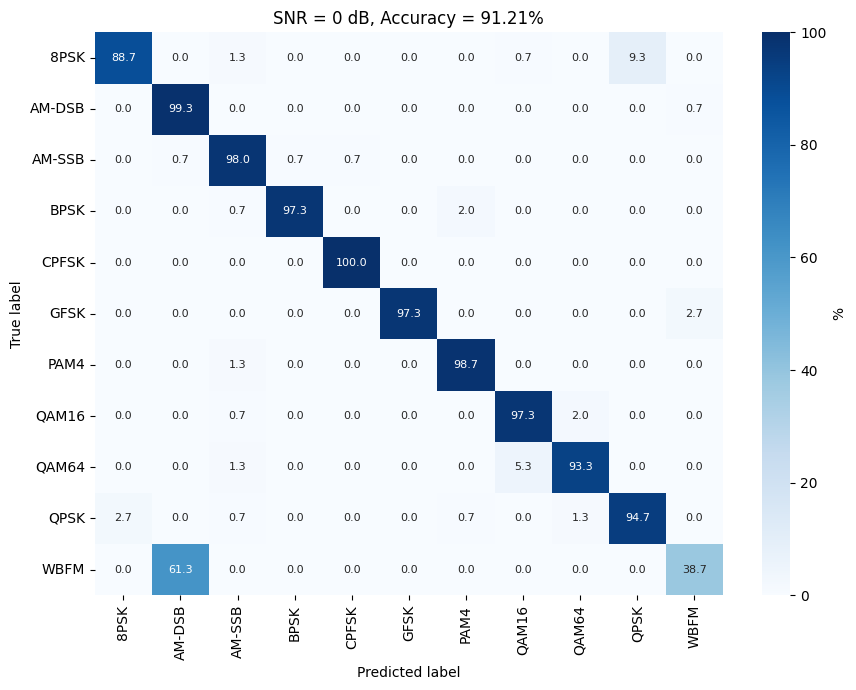

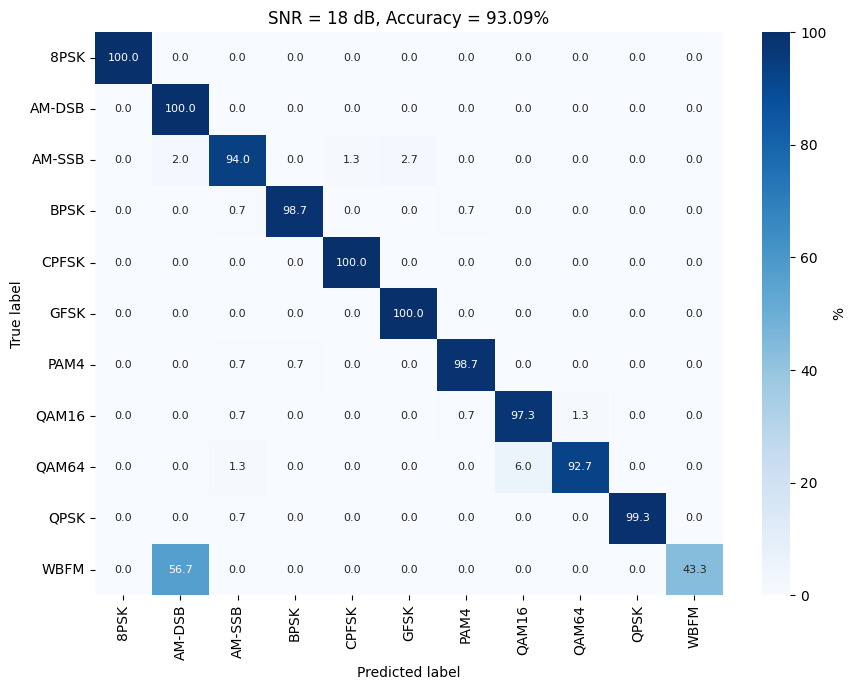

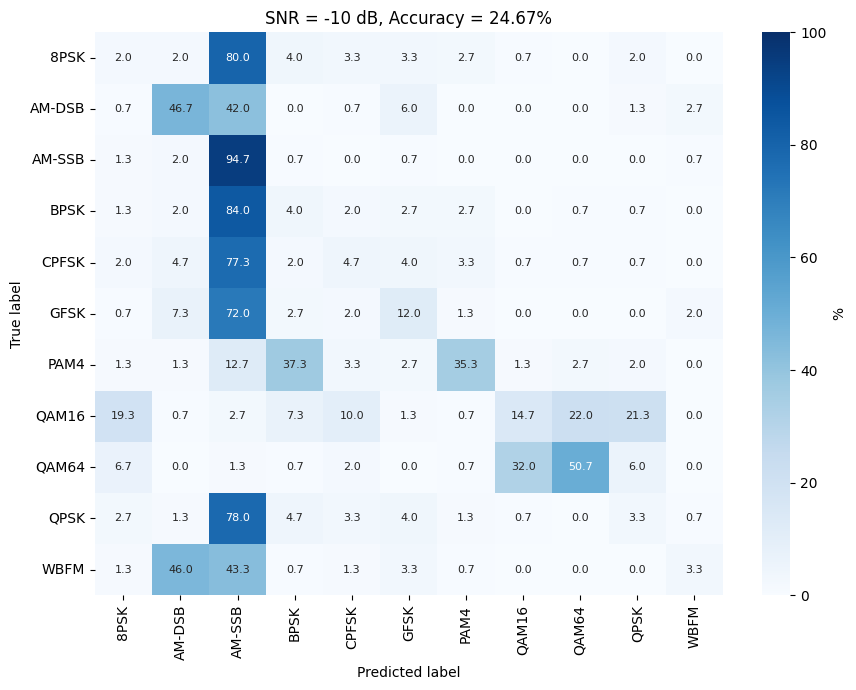

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

classes = ['8PSK','AM-DSB','AM-SSB','BPSK','CPFSK','GFSK','PAM4','QAM16','QAM64','QPSK','WBFM']
os.makedirs('../results/figures', exist_ok=True)

for snr_val in [0, 18, -10]:
    m_ = snrs == snr_val
    cm = confusion_matrix(labels[m_], preds_tta[m_], normalize='true') * 100
    acc = (preds_tta[m_] == labels[m_]).mean() * 100

    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100,
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': '%'}, annot_kws={'size': 8})
    plt.title(f'SNR = {snr_val} dB, Accuracy = {acc:.2f}%')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(f'../results/figures/confusion_{snr_val}dB.png', dpi=300, bbox_inches='tight')
    plt.show()

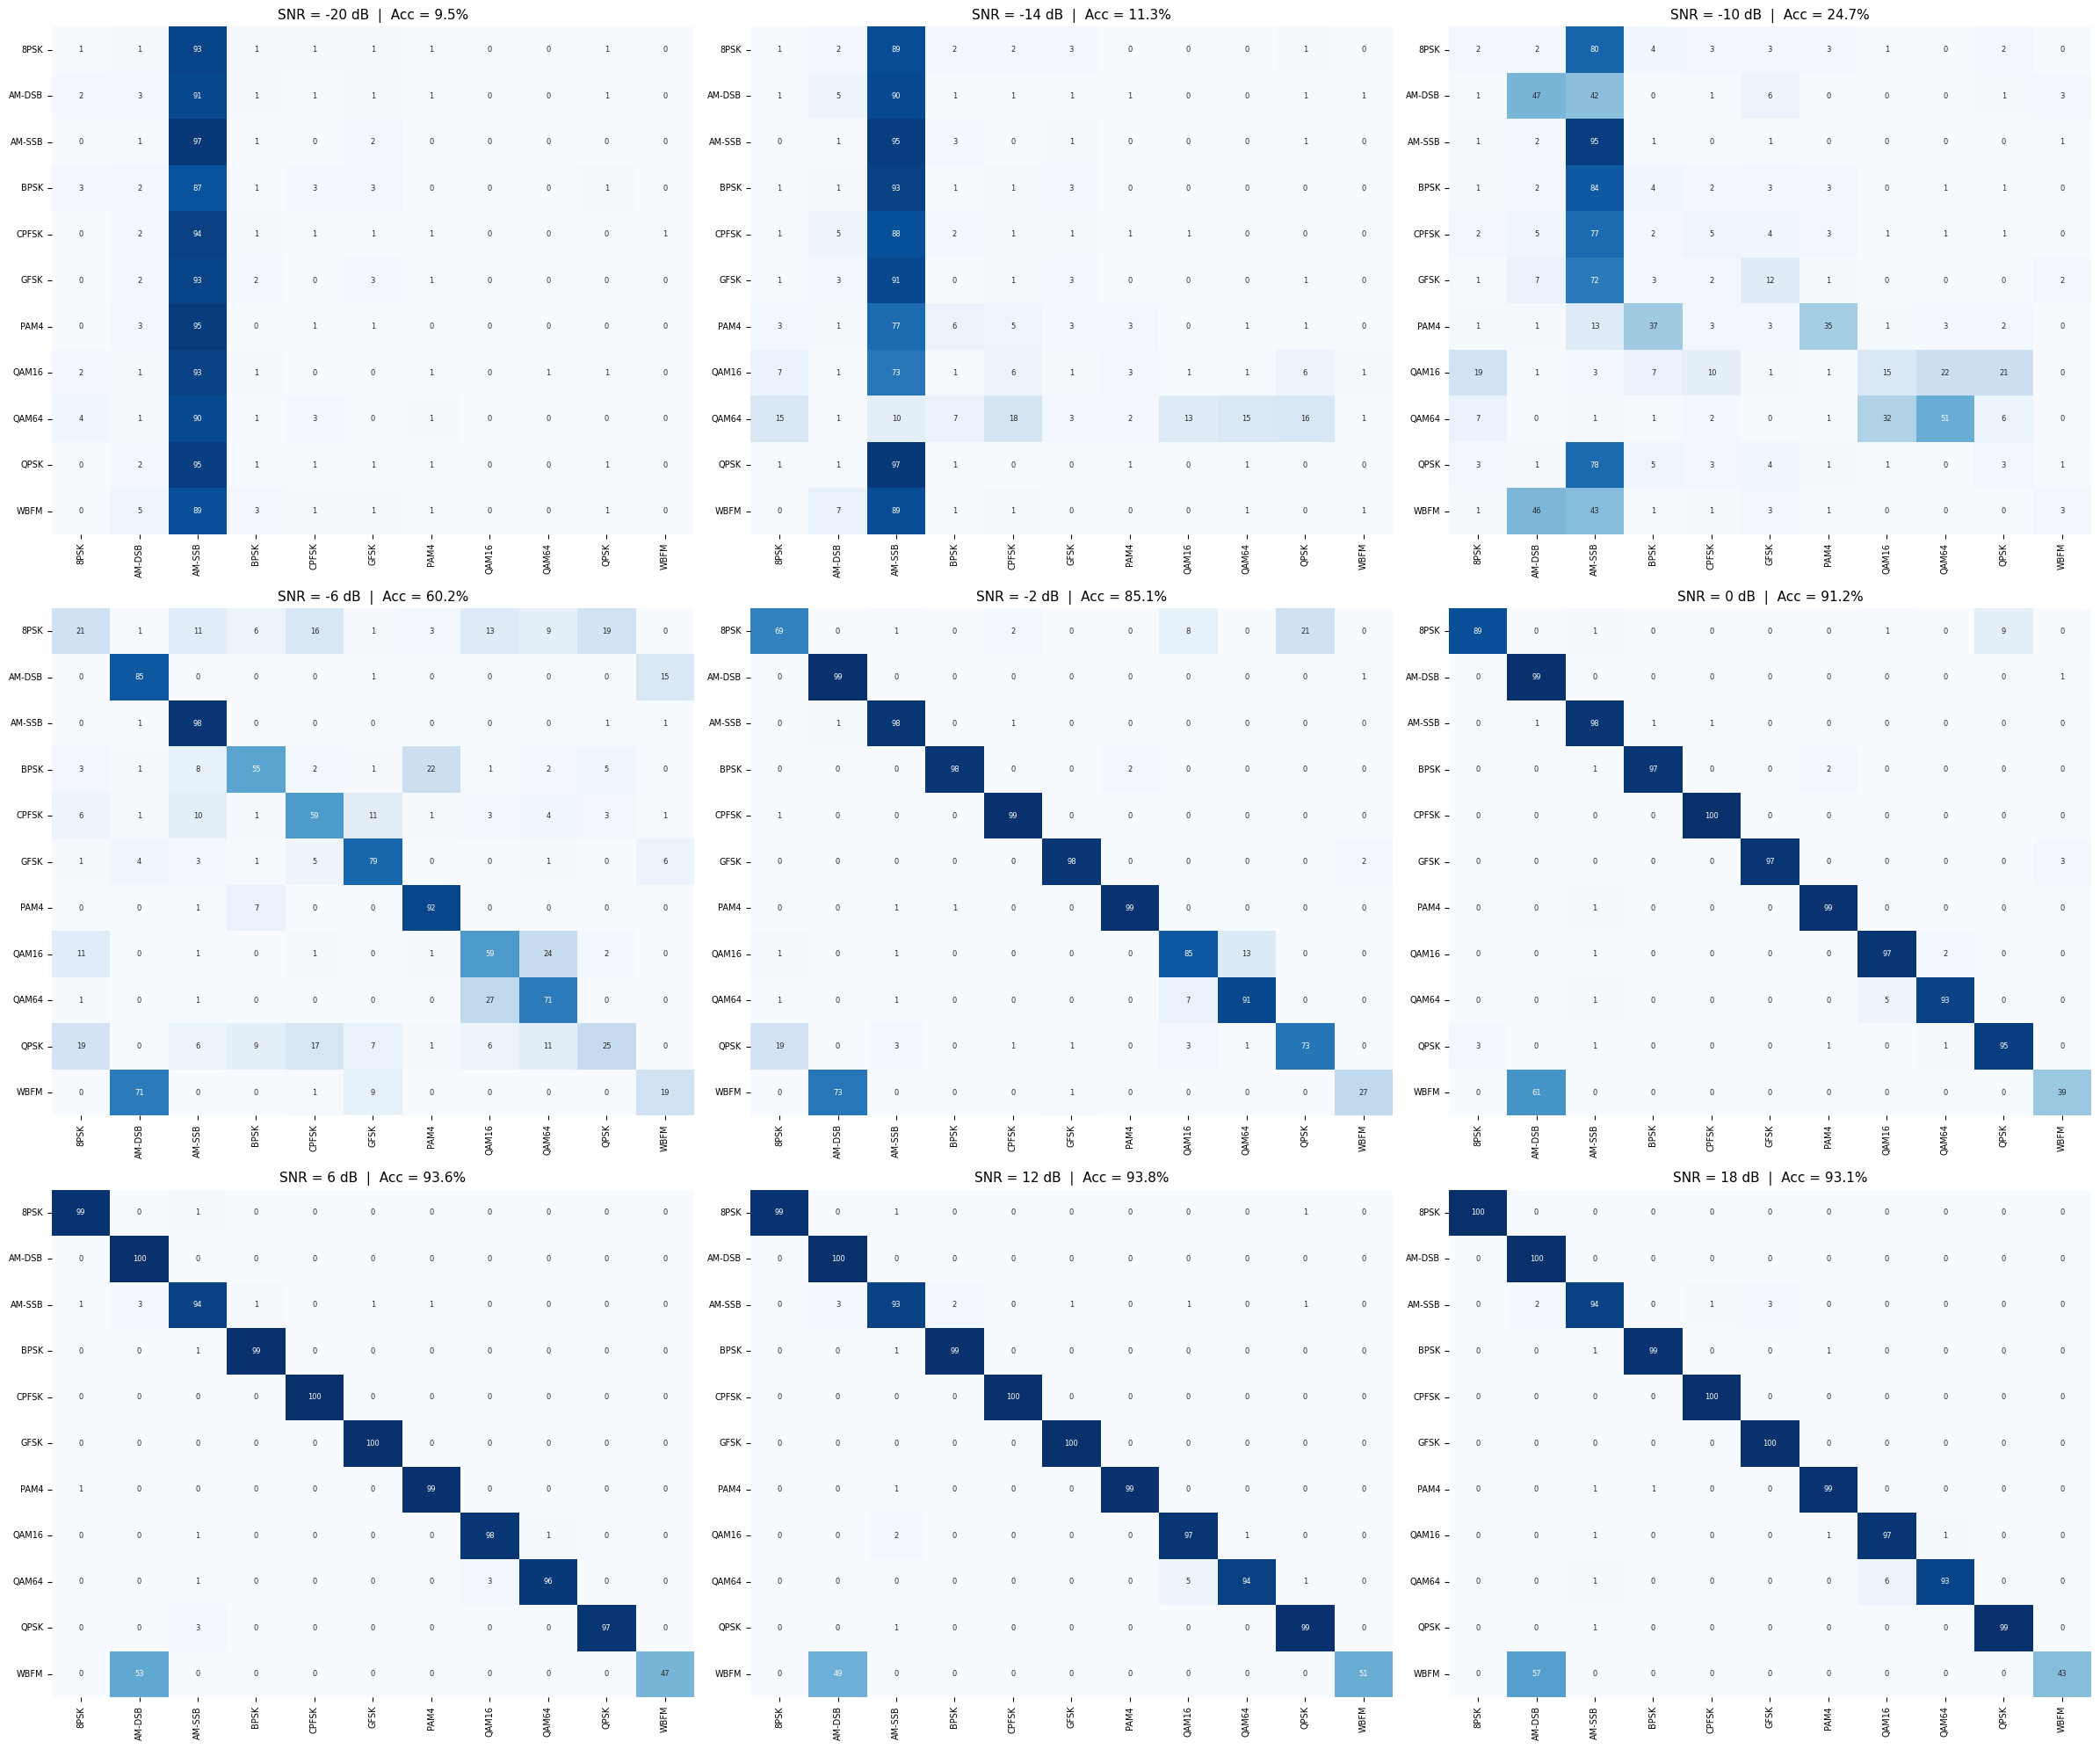

In [12]:
snr_grid = [-20, -14, -10, -6, -2, 0, 6, 12, 18]

fig, axes = plt.subplots(3, 3, figsize=(24, 20))
axes = axes.flatten()

for ax, snr_val in zip(axes, snr_grid):
    m_ = snrs == snr_val
    cm = confusion_matrix(labels[m_], preds_tta[m_], normalize='true') * 100
    acc = (preds_tta[m_] == labels[m_]).mean() * 100

    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=100,
                xticklabels=classes, yticklabels=classes,
                cbar=False, annot_kws={'size': 6}, ax=ax)
    ax.set_title(f'SNR = {snr_val} dB  |  Acc = {acc:.1f}%', fontsize=11)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig('../results/figures/confusion_grid.png', dpi=200, bbox_inches='tight')
plt.show()

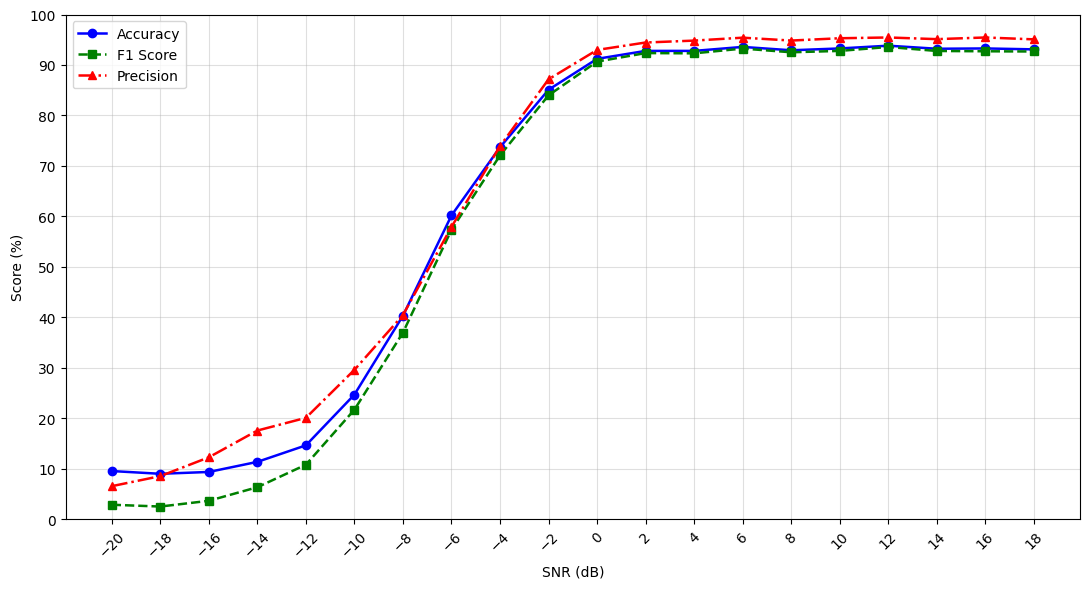

In [14]:
f1_tta_l, prec_tta_l = [], []
for snr_v in unique_snrs:
    m_ = snrs == snr_v
    f1_tta_l.append(f1_score(labels[m_], preds_tta[m_], average='macro', zero_division=0))
    prec_tta_l.append(precision_score(labels[m_], preds_tta[m_], average='macro', zero_division=0))

plt.figure(figsize=(11, 6))
plt.plot(unique_snrs, [a*100 for a in acc_tta_l],  'o-',  color='blue',  label='Accuracy',  linewidth=1.8)
plt.plot(unique_snrs, [f*100 for f in f1_tta_l],   's--', color='green', label='F1 Score',  linewidth=1.8)
plt.plot(unique_snrs, [p*100 for p in prec_tta_l], '^-.', color='red',   label='Precision', linewidth=1.8)
plt.xlabel('SNR (dB)')
plt.ylabel('Score (%)')
plt.xticks(unique_snrs, rotation=45)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 10))
plt.grid(True, alpha=0.4)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../results/figures/metrics_vs_snr.png', dpi=300, bbox_inches='tight')
plt.show()

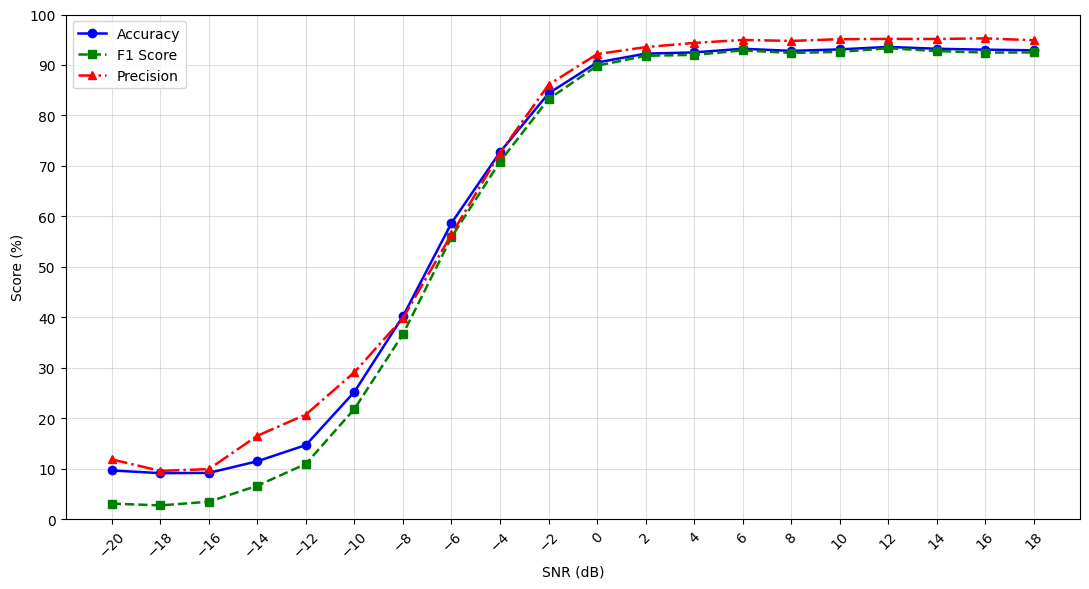

In [15]:
f1_l, prec_l = [], []
for snr_v in unique_snrs:
    m_ = snrs == snr_v
    f1_l.append(f1_score(labels[m_], preds[m_], average='macro', zero_division=0))
    prec_l.append(precision_score(labels[m_], preds[m_], average='macro', zero_division=0))

plt.figure(figsize=(11, 6))
plt.plot(unique_snrs, [a*100 for a in acc_l],  'o-',  color='blue',  label='Accuracy',  linewidth=1.8)
plt.plot(unique_snrs, [f*100 for f in f1_l],   's--', color='green', label='F1 Score',  linewidth=1.8)
plt.plot(unique_snrs, [p*100 for p in prec_l], '^-.', color='red',   label='Precision', linewidth=1.8)
plt.xlabel('SNR (dB)')
plt.ylabel('Score (%)')
plt.xticks(unique_snrs, rotation=45)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 10))
plt.grid(True, alpha=0.4)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../results/figures/metrics_vs_snr_notta.png', dpi=300, bbox_inches='tight')
plt.show()

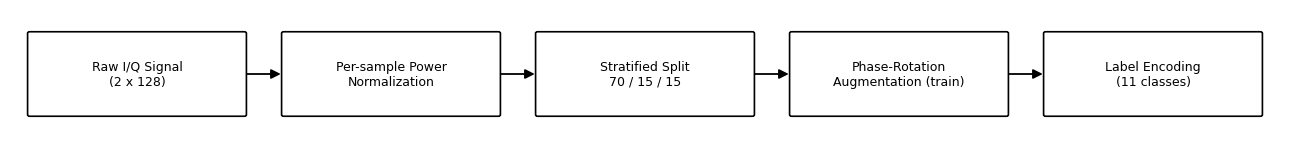

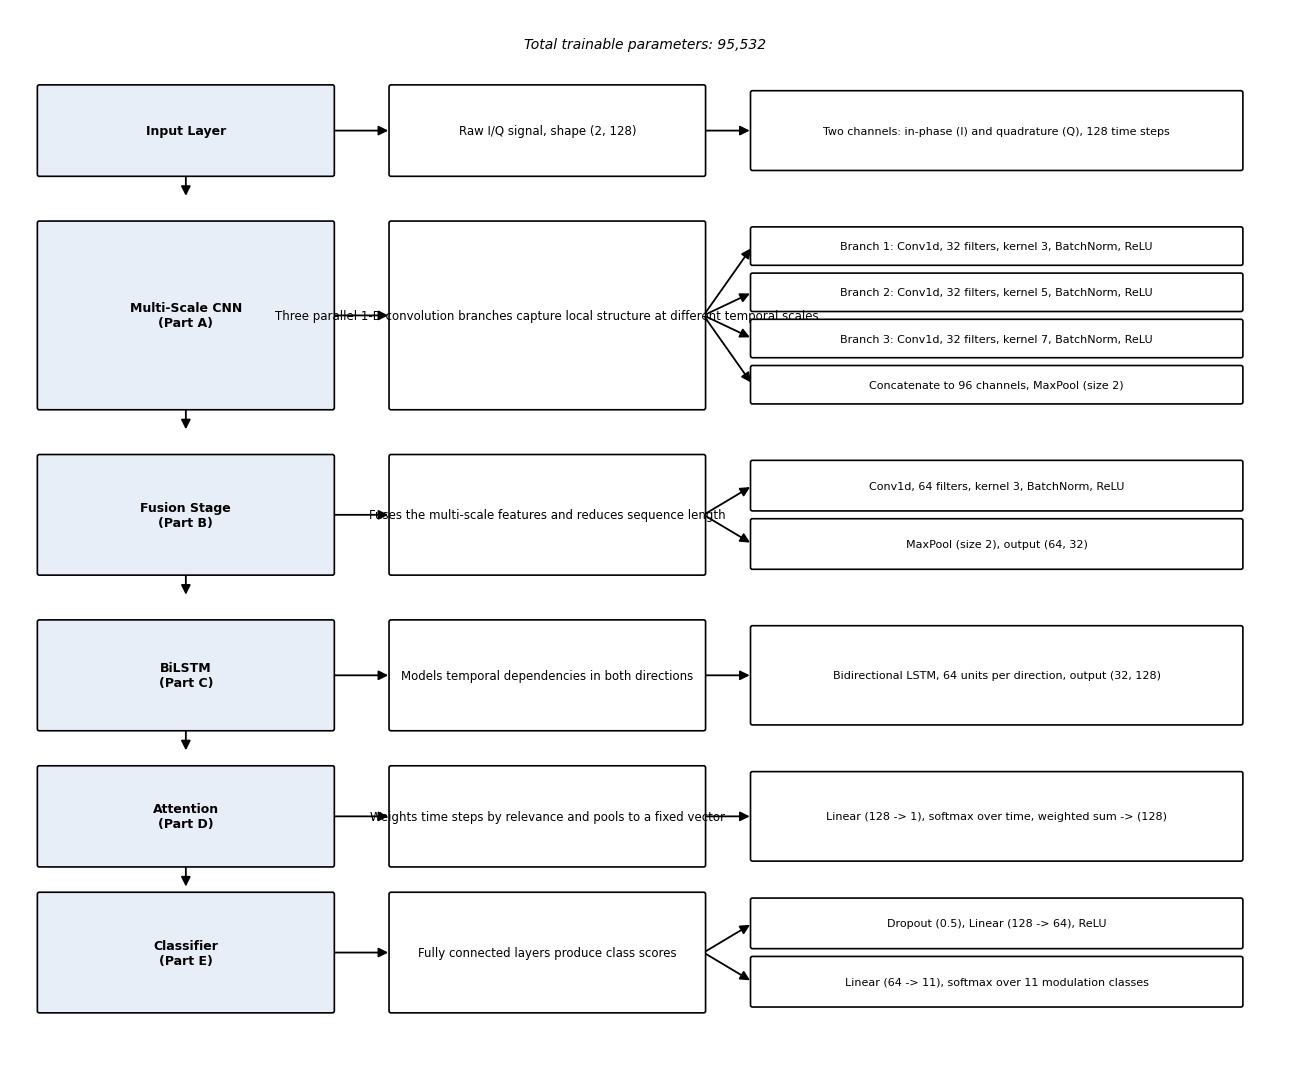

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def box(ax, x, y, w, h, text, fc='white', fs=9, bold=False):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02",
                                fc=fc, ec='black', lw=1.2))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fs, fontweight='bold' if bold else 'normal', wrap=True)

def arrow(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                                 mutation_scale=14, lw=1.3, color='black'))

# ---------- Figure 1: preprocessing pipeline ----------
fig, ax = plt.subplots(figsize=(13, 1.6))
ax.set_xlim(0, 13); ax.set_ylim(0, 1.6); ax.axis('off')

stages = ['Raw I/Q Signal\n(2 x 128)', 'Per-sample Power\nNormalization',
          'Stratified Split\n70 / 15 / 15', 'Phase-Rotation\nAugmentation (train)',
          'Label Encoding\n(11 classes)']
for i, s in enumerate(stages):
    box(ax, 0.2 + i*2.6, 0.3, 2.2, 1.0, s, fs=9)
    if i < len(stages) - 1:
        arrow(ax, 2.4 + i*2.6, 0.8, 2.8 + i*2.6, 0.8)

plt.tight_layout()
plt.savefig('../results/figures/fig_preprocessing.png', dpi=300, bbox_inches='tight')
plt.show()


# ---------- Figure 2: architecture ----------
fig, ax = plt.subplots(figsize=(13, 11))
ax.set_xlim(0, 13); ax.set_ylim(0, 11); ax.axis('off')

L, M, R = 0.3, 3.9, 7.6          # column x positions
LW, MW, RW = 3.0, 3.2, 5.0       # column widths

def stage(y, h, left, mid, rights):
    box(ax, L, y, LW, h, left, fc='#E8EEF7', bold=True)
    box(ax, M, y, MW, h, mid, fs=8.5)
    arrow(ax, L + LW, y + h/2, M, y + h/2)
    n = len(rights)
    rh = h / n - 0.12
    for j, r in enumerate(rights):
        ry = y + h - (j + 1) * (rh + 0.12) + 0.06
        box(ax, R, ry, RW, rh, r, fs=8)
        arrow(ax, M + MW, y + h/2, R, ry + rh/2)

stage(9.3, 0.9, 'Input Layer',
      'Raw I/Q signal, shape (2, 128)',
      ['Two channels: in-phase (I) and quadrature (Q), 128 time steps'])

stage(6.9, 1.9, 'Multi-Scale CNN\n(Part A)',
      'Three parallel 1-D convolution branches ' \
      'capture local structure at different ' \
      'temporal scales',
      ['Branch 1: Conv1d, 32 filters, kernel 3, BatchNorm, ReLU',
       'Branch 2: Conv1d, 32 filters, kernel 5, BatchNorm, ReLU',
       'Branch 3: Conv1d, 32 filters, kernel 7, BatchNorm, ReLU',
       'Concatenate to 96 channels, MaxPool (size 2)'])

stage(5.2, 1.2, 'Fusion Stage\n(Part B)',
      'Fuses the multi-scale features '
      'and reduces sequence length',
      ['Conv1d, 64 filters, kernel 3, BatchNorm, ReLU',
       'MaxPool (size 2), output (64, 32)'])

stage(3.6, 1.1, 'BiLSTM\n(Part C)',
      'Models temporal dependencies in both directions',
      ['Bidirectional LSTM, 64 units per direction, output (32, 128)'])

stage(2.2, 1.0, 'Attention\n(Part D)',
      'Weights time steps by relevance and pools ' \
      'to a fixed vector',
      ['Linear (128 -> 1), softmax over time, weighted sum -> (128)'])

stage(0.7, 1.2, 'Classifier\n(Part E)',
      'Fully connected layers produce class scores',
      ['Dropout (0.5), Linear (128 -> 64), ReLU',
       'Linear (64 -> 11), softmax over 11 modulation classes'])

for y in [9.3, 6.9, 5.2, 3.6, 2.2]:
    arrow(ax, L + LW/2, y, L + LW/2, y - 0.25)

ax.text(6.5, 10.6, 'Total trainable parameters: 95,532',
        ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('../results/figures/fig_architecture.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
for name in ['baseline', 'multiscale']:
    m = MODELS[name]()
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:12s}: {total:,} total | {trainable:,} trainable")

baseline    : 88,716 total | 88,716 trainable
multiscale  : 95,532 total | 95,532 trainable
